In [4]:
# Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

Збір даних

Перш за все, потрібно зібрати дані з акселерометра мобільного телефону.

In [5]:
from pathlib import Path
activities = ['idle', 'running', 'stairs', 'walking']
data_collections = []

for index, activity in enumerate(activities, start=1):
    activity_path = Path('data') / activity
    csv_files = list(activity_path.glob('*.csv'))
    df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)
    df['activity'] = activity
    data_collections.append(df)

data = pd.concat(data_collections, ignore_index=True)
data

,accelerometer_X,accelerometer_Y,accelerometer_Z,activity
0,1.000776,4.616021,8.576031,idle
1,0.718261,4.209007,8.446744,idle
2,-0.909797,-0.282516,9.203311,idle
3,5.099650,0.148441,8.418014,idle
4,1.762132,-0.162806,9.251195,idle
...,...,...,...,...
193855,5.109226,-15.452178,-1.470040,walking
193856,6.373365,-11.741165,-8.226476,walking
193857,3.289633,-9.993398,-0.383072,walking
193858,-2.978387,-3.050213,1.273715,walking


Тренування на вихідних нормалізованих данних

В якості характеристик візьмемо показники з акселерометра

In [6]:
features = ['accelerometer_X', 'accelerometer_Y', 'accelerometer_Z']

Нормалізація даних

Тренування на ненормалізованих даних займає чимало часу. Вхідні дані нормалізуються так, щоб їхнє середнє значення дорівнювало нулю, а стандартне відхилення - одиниці.

In [7]:
scaler = StandardScaler()

data_to_normalize = data[features]

# Нормалізація даних
normalized_data = scaler.fit_transform(data_to_normalize)

# Заміна вихідних даних нормалізованими даними
ndata = data.copy()
ndata[features] = normalized_data
ndata

,accelerometer_X,accelerometer_Y,accelerometer_Z,activity
0,-0.109791,0.241917,0.941538,idle
1,-0.143404,0.209288,0.923560,idle
2,-0.337109,-0.150782,1.028762,idle
3,0.377889,-0.116234,0.919565,idle
4,-0.019205,-0.141185,1.035420,idle
...,...,...,...,...
193855,0.379029,-1.366884,-0.455385,walking
193856,0.529435,-1.069384,-1.394879,walking
193857,0.162535,-0.929271,-0.304241,walking
193858,-0.583227,-0.372659,-0.073862,walking


Розділяємо дані

Розділяємо датасет на навчальний і тестовий набори

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    data[features], data["activity"],
    test_size=0.3,
    stratify=ndata["activity"],
)

Навчаємо за допомогою алгоритму SVM

In [9]:
%%time

model_svm = SVC()
model_svm.fit(X_train, y_train)

CPU times: total: 4min 48s
Wall time: 6min 20s


SVC()

Навчаємо за допомогою алгоритму випадкового лісу

In [10]:
%%time

model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train, y_train)

CPU times: total: 21.4 s
Wall time: 24.6 s


RandomForestClassifier()

Порівнюємо точність результатів

Визначаємо точність моделей на тестовому наборі та порівнюємо

In [11]:
score_svm = model_svm.score(X_test, y_test)
score_rf = model_rf.score(X_test, y_test)

print(f"Точність моделі SVM: {score_svm:.3f}")
print(f"Точність моделі випадкового лісу: {score_rf:.3f}")

Точність моделі SVM: 0.894
Точність моделі випадкового лісу: 1.000


Пргнозування

In [12]:
y_predicted_svm = model_svm.predict(X_test)
y_predicted_rf = model_rf.predict(X_test)

Побудуємо матрицю помилок (confusion matrix).

Матрицю помилок - це таблиця, яку використовують для оцінювання продуктивності класифікаційної моделі. Вона дає змогу порівняти фактичні та передбачені класифікатором мітки для кожного об'єкта в тестовій вибірці.

In [13]:
conf_matrix_svm = confusion_matrix(y_test, y_predicted_svm)
conf_matrix_rf = confusion_matrix(y_test, y_predicted_rf)

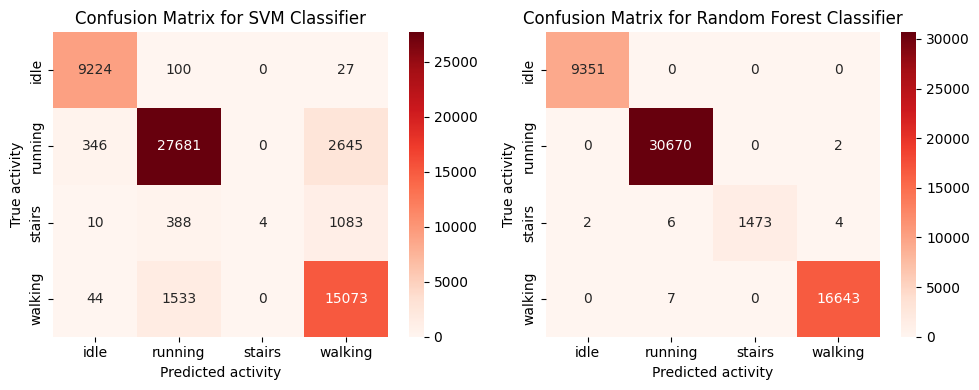

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

classifiers = ["SVM", "Random Forest"]
confusion_matrices = [conf_matrix_svm, conf_matrix_rf]

for i, classifier in enumerate(classifiers):
    sns.heatmap(
        confusion_matrices[i],
        annot=True,
        fmt='d',
        cmap='Reds',
        xticklabels=activities,
        yticklabels=activities,
        ax=axes[i],
    )
    axes[i].set_title(f"Confusion Matrix for {classifier} Classifier")
    axes[i].set_xlabel("Predicted activity")
    axes[i].set_ylabel("True activity")

plt.tight_layout()

plt.show()

Тренування на підготовленних даних

В статті [1] пропонується обрати наступні часові ознаки (таблиця 3). Як пишуть автори, їхні результати показують, що найбільш репрезентативні ознаки отримані з часового представлення сигналу акселерометра. Ознаки, витягнуті з сигналів по осях  x  і  y  є більш релевантними, ніж ознаки по осі  z  при визначенні активності.

Name	Axis
Maximum Value	x
Minimum Value	x
Entropy	x
Interquartile Range	x
Maximum Value	y
Index of Minimum Value	y
Mean of Absolute Deviation	y
Median	y
Skewness	y
Standard Deviation	y
Root Mean Square Error	y
Skewness	z


Створення необхідних функцій

In [16]:
def iqr(data):
    """Calculates the interquartile range (IQR) of a dataset.

    The IQR is the difference between the 75th and 25th percentiles of the data,
    and is a measure of the spread of the middle 50% of the data.

    Args:
        data: A NumPy array or Pandas Series containing the data.

    Returns:
        The IQR of the data.
    """
    sorted_data = np.sort(data)

    Q1 = np.percentile(sorted_data, 25)
    Q3 = np.percentile(sorted_data, 75)

    IQR = Q3 - Q1

    return IQR

def argmin(data):
    """Returns the index of the minimum value in a dataset.

    Args:
        data: A NumPy array or Pandas Series containing the data.

    Returns:
        The index of the minimum value in the data.
    """
    return np.argmin(data)

def entropy(column_data):
    """Calculates the entropy of a column of data.

    Entropy is a measure of uncertainty or randomness in a set of data. It is calculated as follows:

    ```
    H = -sum(pk * log2(pk))
    ```

    where pk is the probability of each value in the data set.

    Args:
        column_data: A NumPy array or Pandas Series containing the data.

    Returns:
        The entropy of the data.
    """

    hist, bins = np.histogram(column_data, bins='auto')
    probs = hist / len(column_data)

    probs = probs[probs > 0]

    entropy = -np.sum(probs * np.log2(probs))

    return entropy

def mad(data):
    """Calculates the median absolute deviation (MAD) of a dataset.

    The MAD is a measure of the spread of the data, and is calculated as the median of the absolute deviations from the median. It is a more robust measure of spread than the standard deviation, as it is less sensitive to outliers.

    Args:
        data: A NumPy array or Pandas Series containing the data.

    Returns:
        The MAD of the data.
    """
    mean = np.mean(data)

    absolute_deviations = np.abs(data - mean)

    mad = np.mean(absolute_deviations)

    return mad

def rmse(data):
    """Calculates the root mean square error (RMSE) of a dataset.

    The RMSE is a measure of the average difference between the actual values in the dataset and the predicted values. It is calculated as follows:

    ```
    RMSE = sqrt(mean((y_true - y_pred)**2))


    where:

    * `y_true` is the actual values in the dataset
    * `y_pred` is the predicted values

    The RMSE is a good measure of fit for regression models, and is often used to evaluate the performance of a model on a held-out test set.

    Args:
        data: A NumPy array or Pandas Series containing the data.

    Returns:
        The RMSE of the data.
    """

    mean = np.mean(data)

    squared_errors = [(x - mean) ** 2 for x in data]

    rmse = np.sqrt(np.mean(squared_errors))

    return rmse

Створення датасету на основі ознак, вказанних в статті

In [17]:
axis_aggregations = {
    'accelerometer_X': ["max", "min", entropy, iqr],
    'accelerometer_Y': ["max", argmin, mad, "median", "skew", "std", rmse],
    'accelerometer_Z': ["skew"]
}

data_tdf = pd.DataFrame()


for axis, functions in axis_aggregations.items():
    axis_data = ndata.groupby(["activity", ndata.index // 30])[axis].agg(functions)

    multiindex = pd.MultiIndex.from_product([[axis], axis_data.columns])

    axis_data.columns = multiindex
    data_tdf = pd.concat([data_tdf, axis_data], axis=1)

data_tdf.reset_index(level=0, inplace=True)

In [18]:
# Утворений датасет на основі ознак таблиці 3 статті [1]

data_tdf

activity accelerometer_X                               accelerometer_Y  \
                          max       min   entropy       iqr             max   
0        idle        0.377889 -0.337109  3.075701  0.007834        0.241917   
1        idle       -0.180436 -0.267033  2.732915  0.004700       -0.126214   
2        idle       -0.236268 -0.243675  2.389898  0.002564       -0.108556   
3        idle       -0.162205 -0.196958  2.663458  0.005982       -0.121224   
4        idle       -0.162205 -0.196958  2.384778  0.006125       -0.121224   
...       ...             ...       ...       ...       ...             ...   
6457  walking        0.626857 -0.941581  2.507218  0.666429       -0.113547   
6458  walking        0.626857 -1.104521  2.421421  0.599060       -0.113547   
6459  walking        1.093457 -1.104521  2.295601  0.595784       -0.113547   
6460  walking        1.093457 -1.104521  2.441946  0.525424       -0.113547   
6461  walking        1.093457 -1.104521  2.380542  0.770973       -0.113547   

                                                              accelerometer_Z  
     argmin       mad    median      skew       std      rmse            skew  
0         2  0.045375 -0.138690  3.647470  0.092801  0.091241       -2.365312  
1         7  0.002278 -0.138690  0.568223  0.003853  0.003788       -2.409922  
2        14  0.000966 -0.110092 -1.272920  0.001313  0.001291       -0.097477  
3        28  0.003037 -0.129861 -0.857829  0.004371  0.004298        0.565957  
4        26  0.002952 -0.129669 -1.001079  0.004329  0.004257        0.453139  
...     ...       ...       ...       ...       ...       ...             ...  
6457     18  0.328695 -0.963052 -0.540493  0.423706  0.416584        1.221757  
6458     16  0.334778 -0.963052 -0.523121  0.427288  0.420106        1.178148  
6459     14  0.346932 -0.963052 -0.453662  0.433905  0.426612        1.996085  
6460     12  0.331504 -0.989731 -0.365569  0.424419  0.417285        1.959435  
6461     10  0.339666 -0.963052 -0.354875  0.436354  0.429020        1.950320  

[6462 rows x 13 columns]

Розділяємо датасет на навчальний і тестовий набори

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    data_tdf[features], data_tdf["activity"],
    test_size=0.3,
    stratify=data_tdf["activity"],
)

Навчаємо за домомогою алгоритму SVN

In [20]:
%%time

model_svm = SVC()
model_svm.fit(X_train, y_train)

CPU times: total: 562 ms
Wall time: 1.15 s


SVC()

Навчаємо за домомогою алгоритму random forest

In [21]:
%%time

model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train, y_train)

CPU times: total: 1.73 s
Wall time: 3.75 s


RandomForestClassifier()

Визначаємо точність моделей на тестовому наборі

In [22]:
score_svm = model_svm.score(X_test, y_test)
score_rf = model_rf.score(X_test, y_test)

print(f"Точність моделі SVM: {score_svm:.3f}")
print(f"Точність моделі випадкового лісу: {score_rf:.3f}")

Точність моделі SVM: 0.974
Точність моделі випадкового лісу: 0.998


Прогнозування

In [23]:
y_predicted_svm = model_svm.predict(X_test)
y_predicted_rf = model_rf.predict(X_test)

Побудуємо матрицю помилок confusion matrix

In [24]:
conf_matrix_svm = confusion_matrix(y_test, y_predicted_svm)
conf_matrix_rf = confusion_matrix(y_test, y_predicted_rf)

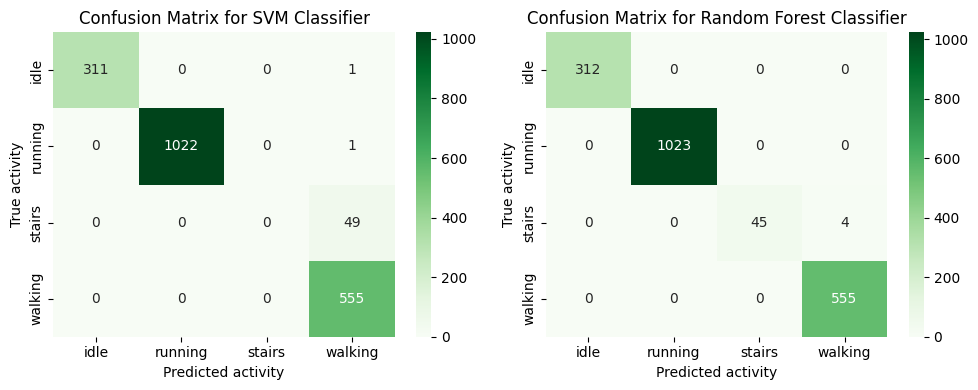

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

classifiers = ["SVM", "Random Forest"]
confusion_matrices = [conf_matrix_svm, conf_matrix_rf]

for i, classifier in enumerate(classifiers):
    sns.heatmap(
        confusion_matrices[i],
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=activities,
        yticklabels=activities,
        ax=axes[i],
    )
    axes[i].set_title(f"Confusion Matrix for {classifier} Classifier")
    axes[i].set_xlabel("Predicted activity")
    axes[i].set_ylabel("True activity")

plt.tight_layout()

plt.show()

Як видно, класифікатор SVM на тестових даних помилився у всіх 49 випадках, класифікувавши ходіння по сходах (stairs) як прогулянку (walking). Тобто, зовсім не розпізнає ходіння по сходах.

Класифікатор ramdom forest на тестових даних помилився лише в 5 випадках, класифікувавши ходіння по сходах (stairs) як прогулянку (walking).

Слід сказати. що набір даних для stairs був найменшим з усіх інших. Тому тут бажано було б набрати більше даних, тоді може SVM дав би кращі результати.

Результати та висновки
Для навчання алгоритму SVN на вихідних ознаках (показах акселерометра по трьох осях) потрібно близько 20 хвилин на стандартному комп'ютері. Навчання на вихідних ознаках (показах акселерометра по трьох осях) спричиняє довге навчання, оскільки алгоритм SVN має велику кількість параметрів, які потрібно оптимізувати. Це пов'язано з тим, що алгоритм SVN намагається знайти оптимальну підмножину ознак, яка найкраще класифікує дані. У випадку з даними про рух людини, які мають багато шуму і невизначеності, це може бути дуже складним завданням.

Навчання на нормалізованих ознаках акселерометра по трьох осях зменшує час навчання алгоритму SVN близько 4 хвилин. Навчання на нормалізованих величинах акселерометра по трьох осях дає значний виграш при навчання по методу SVN. Нормалізація показів акселерометра по трьох осях усуває масштабування, яке може призвести до переваги одних ознак над іншими. Це також робить дані більш однорідними, що полегшує задачу навчання алгоритму SVN.

час розрахунку близько 13 секунд;
точність близька до 0.89.
Навчання за методом випадкового лісу показує кращу точність та набагато менший час навчання, оскільки це більш стійкий до шуму і невизначеності алгоритм. Метод випадкового лісу генерує декілька дерев рішень, і кожен з них голосує за класифікацію. Це дозволяє алгоритму випадкового лісу бути більш точним, ніж алгоритм SVN, який генерує лише одне дерево рішень. Крім того, метод випадкового лісу має набагато меншу кількість параметрів, ніж алгоритм SVN, що також сприяє його більш швидкому навчанню.

час розрахунку близько 13 секунд;
точність близька до 1.00.
Навчання, де в якості ознак взяті статистичні ознаки запропоновані в статті [1], отримані по набору з 30 показників акселерометра для кожної осі  x ,  y  та  z  показує:

точність моделі SVM значно підвищилась до значення 0.975, крім того час навчання значно зменшився і становить 46.9 ms.
точність моделі random forest також підвищилась в порівнянні з навчанням на вихідних нормалізованих судячи з матриці помилок, також час навчання становить 766 ms, що значно менше ніж для навчання на вихідних нормалізованих даних, але натомість він на порядок вище в порявнянні з моделлю SVN.
Таблиця з результатами

Таблиця. Результати
Тип ознак	Алгоритм	Час розрахунку	Точність
вихідні нормалізовані	SVN	240 s	0.89
Random Forest	13 s	~ 1.00
статистичні дані	SVN	46.9 ms	0.98
Random Forest	766 ms	~ 1.00
Згідно таблиці, можна зробити висновок, що найкращі результати дає в сенсі час/чточність дає алгоритм random forest, який тренувався не на вихідних, а на статистичних ознаках. Ці висновки також підтверджуються аналізом матриці помилок, показує, що класифікатор random forest помиляється значно менше, ніж SVM. Використання статистичних даних, порівняно з сирими підвищує точність класифікації та знижує час навчання.